In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import re, html, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
# load data 
BASE_PATH = './data/'
abstract_raw = pd.read_excel(BASE_PATH + 'grants-with-abstract.xlsx',
                             sheet_name='Grants with abstract (2).csv')
aa = abstract_raw[abstract_raw['Sourcetype'] == 'AA'].copy()
aa = aa.dropna(subset=['Abstract'])
aa['Start Date'] = pd.to_datetime(aa['Start Date'], errors='coerce')
aa['Year'] = aa['Start Date'].dt.year
print(f'Loaded {len(aa):,} abstracts')

Loaded 2,873 abstracts


In [3]:
# full cleaning pipeline
def remove_nsf_boilerplate(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'(?i)intellectual\s+merit\s*[:.*\-]?.*?(broader\s+impacts|$)', ' ', text, flags=re.DOTALL)
    text = re.sub(r'(?i)broader\s+impacts\s*[:.*\-]?.*', ' ', text, flags=re.DOTALL)
    return text.strip()

def clean_text(text):
    if not isinstance(text, str): return ''
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&\w+;', ' ', text)
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'-', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\[unreadable\]', ' ', text)
    text = re.sub(r'description\s*\(?provided by applicant\)?:?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'project\s+summary', ' ', text, flags=re.IGNORECASE)
    return text

aa['abstract_clean'] = aa['Abstract'].apply(remove_nsf_boilerplate)
aa['full_text_clean'] = (
    aa['Title'].fillna('').apply(clean_text) + ' ' +
    aa['abstract_clean'].fillna('').apply(clean_text)
)

try:
    import nltk
    from nltk.stem import WordNetLemmatizer
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    lemmatizer = WordNetLemmatizer()
    aa['full_text_lemma'] = aa['full_text_clean'].apply(
        lambda t: ' '.join(lemmatizer.lemmatize(w) for w in t.split()))
    print('Lemmatization done.')
except ImportError:
    aa['full_text_lemma'] = aa['full_text_clean']
    print('nltk not found — skipping lemmatization.')

print('Cleaning done.')

Lemmatization done.
Cleaning done.


In [4]:
# stopword list
grant_noise = {
    'research', 'project', 'award', 'grant', 'proposal', 'funded', 'funding',
    'investigator', 'principal', 'collaborative', 'collaboration', 'team',
    'work', 'working', 'study', 'studies', 'aims', 'aim', 'goal', 'goals',
    'proposed', 'propose', 'objective', 'objectives', 'researcher',
    'university', 'northeastern', 'national', 'science', 'engineering',
    'foundation', 'center', 'institute', 'program', 'programs',
    'support', 'supported', 'faculty', 'student', 'students', 'graduate',
    'undergraduate', 'education', 'educational', 'laboratory', 'lab', 'user',
    'conference', 'workshop', 'training', 'infrastructure', 'activities',
    'activity', 'mission', 'scientific', 'data', 'device', 'tool', 'method',
    'analysis', 'technique', 'area', 'represent', 'representation',
    'develop', 'development', 'developed', 'developing','model',
    'provide', 'provides', 'provided', 'providing',
    'include', 'including', 'includes', 'included',
    'approach', 'approaches', 'novel', 'new', 'enable', 'enabled',
    'use', 'used', 'using', 'uses', 'based',
    'result', 'results', 'resulting', 'impact', 'impacts',
    'important', 'significant', 'key', 'critical', 'potential',
    'ability', 'demonstrate', 'understand', 'understanding', 'change', 'changes', 'advance', 'advances', 'advanced',
    'require', 'required', 'design', 'implement', 'implementation',
    'explore', 'consider', 'address', 'advance', 'advances', 'advanced',
    'high', 'large', 'small', 'specific', 'general', 'current', 'real',
    'different', 'multiple', 'fundamental', 'future', 'complex', 'effect',
    'knowledge', 'performance', 'framework', 'process', 'processes', 'need',
    'public', 'community', 'multi', 'groups', 'group', 'problem', 'problems',
    'time', 'state', 'level', 'scale', 'field', 'experiment', 'challenge', 'school', 'college',
    'intellectual', 'merit', 'broader', 'criteria', 'criterion', 'deemed', 'technology',
    'worthy', 'statutory', 'reflects', 'review',
    'andgt', 'andlt', 'nbsp', 'amp', 'br', 'ha', 
    'nsf', 'reu', 'stem',
    'participant', 'opportunity', 'diverse', 'diversity', 'minority',
    'institution', 'professional', 'career', 'experience',
    'will', 'also', 'well', 'can', 'may', 'such', 'thus',
    'this', 'these', 'their', 'been', 'have', 'from',
}
all_stops = list(set(ENGLISH_STOP_WORDS) | grant_noise)
print(f'Total stopwords: {len(all_stops):,}')

Total stopwords: 497


In [5]:
# refit NMF and LDA
N_TOPICS = 8

tfidf_vec = TfidfVectorizer(stop_words=all_stops, ngram_range=(1, 2),
                             max_features=3000, min_df=5, max_df=0.60)
count_vec = CountVectorizer(stop_words=all_stops, ngram_range=(1, 2),
                             max_features=3000, min_df=5, max_df=0.60)

tfidf_matrix = tfidf_vec.fit_transform(aa['full_text_lemma'])
count_matrix = count_vec.fit_transform(aa['full_text_lemma'])

nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=400)
nmf_doc_topics = nmf.fit_transform(tfidf_matrix)

lda = LatentDirichletAllocation(n_components=N_TOPICS, max_iter=25,
                                  learning_method='online', random_state=42, n_jobs=-1)
lda_doc_topics = lda.fit_transform(count_matrix)

aa['nmf_topic'] = nmf_doc_topics.argmax(axis=1)
aa['lda_topic'] = lda_doc_topics.argmax(axis=1)

nmf_labels = {
    0: 'AI & Machine Learning',
    1: 'Biomedical & Cancer Biology',
    2: 'Pure Mathematics',
    3: 'Networking & Communications',
    4: 'Materials Science & Condensed Matter',
    5: 'Public Health, Environment & Climate',
    6: 'Particle Physics',
    7: 'STEM Education & Broadening Participation',
}
lda_labels = {
    0: 'Environment & Climate',
    1: 'Networking & Communications',
    2: 'Public Health & Society',
    3: 'STEM Education & Broadening Participation',
    4: 'Physics & Materials Science',
    5: 'Cognitive & Computational Modeling',
    6: 'Biomedical & Molecular Biology',
    7: 'AI & Computer Science',
}
aa['nmf_label'] = aa['nmf_topic'].map(nmf_labels)
aa['lda_label'] = aa['lda_topic'].map(lda_labels)

print('Models refit. NMF topic counts:')
print(aa['nmf_label'].value_counts().to_string())

Models refit. NMF topic counts:
nmf_label
Public Health, Environment & Climate         904
Materials Science & Condensed Matter         465
Biomedical & Cancer Biology                  363
Networking & Communications                  356
AI & Machine Learning                        298
STEM Education & Broadening Participation    267
Pure Mathematics                             139
Particle Physics                              81


## 1. Topic Coherence, Are the Topics Internally Consistent?

In [6]:
# coherence score using NPMI (normalized pointwise mutual information)
# measures how often top words in a topic actually co-occur in documents
# higher = more coherent topic; range roughly -1 to 1, good topics score > 0.1
from itertools import combinations

def compute_coherence(model, vectorizer, docs_matrix, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    scores = []
    n_docs = docs_matrix.shape[0]

    for topic in model.components_:
        top_idx   = topic.argsort()[:-top_n - 1:-1]
        top_words = [feature_names[i] for i in top_idx]
        word_cols = [np.asarray(docs_matrix[:, i].todense()).flatten() > 0 for i in top_idx]

        pair_scores = []
        for (i, wi), (j, wj) in combinations(enumerate(top_words), 2):
            co_occur = np.sum(word_cols[i] & word_cols[j]) + 1  # +1 smoothing
            p_i  = (np.sum(word_cols[i]) + 1) / n_docs
            p_j  = (np.sum(word_cols[j]) + 1) / n_docs
            p_ij = co_occur / n_docs
            npmi = np.log(p_ij / (p_i * p_j)) / (-np.log(p_ij))
            pair_scores.append(npmi)
        scores.append(np.mean(pair_scores))
    return scores

nmf_coherence = compute_coherence(nmf, tfidf_vec, tfidf_matrix)
lda_coherence = compute_coherence(lda, count_vec, count_matrix)

print('NMF coherence per topic (higher = more coherent):')
for i, score in enumerate(nmf_coherence):
    print(f'  {nmf_labels[i]:<45} {score:.3f}')
print(f'  Mean NMF coherence: {np.mean(nmf_coherence):.3f}')
print()
print('LDA coherence per topic:')
for i, score in enumerate(lda_coherence):
    print(f'  {lda_labels[i]:<45} {score:.3f}')
print(f'  Mean LDA coherence: {np.mean(lda_coherence):.3f}')

NMF coherence per topic (higher = more coherent):
  AI & Machine Learning                         0.210
  Biomedical & Cancer Biology                   0.316
  Pure Mathematics                              0.457
  Networking & Communications                   0.301
  Materials Science & Condensed Matter          0.242
  Public Health, Environment & Climate          0.122
  Particle Physics                              0.603
  STEM Education & Broadening Participation     0.280
  Mean NMF coherence: 0.317

LDA coherence per topic:
  Environment & Climate                         0.179
  Networking & Communications                   0.166
  Public Health & Society                       0.229
  STEM Education & Broadening Participation     0.219
  Physics & Materials Science                   0.110
  Cognitive & Computational Modeling            0.199
  Biomedical & Molecular Biology                0.257
  AI & Computer Science                         0.201
  Mean LDA coherence: 0.195


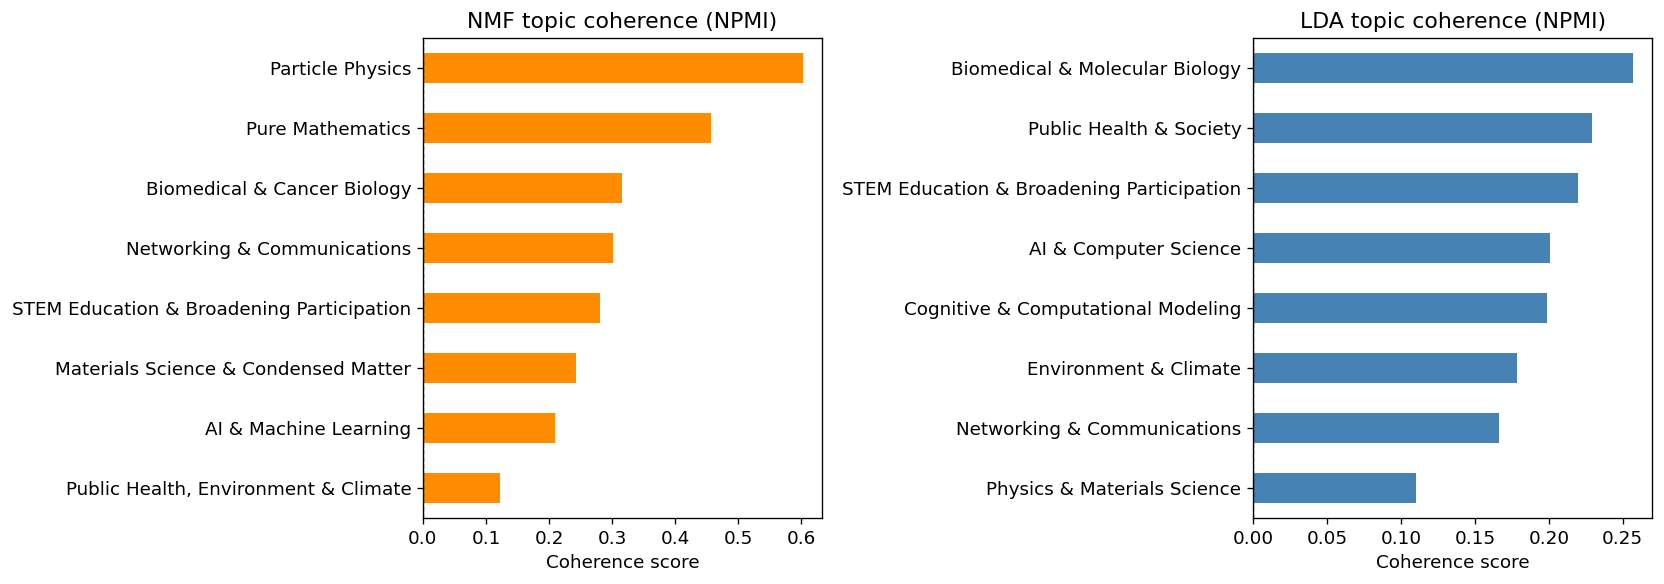

In [7]:
# bar chart comparing NMF vs LDA coherence per topic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(nmf_coherence, index=[nmf_labels[i] for i in range(N_TOPICS)]).sort_values().plot(
    kind='barh', ax=axes[0], color='darkorange')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('NMF topic coherence (NPMI)')
axes[0].set_xlabel('Coherence score')

pd.Series(lda_coherence, index=[lda_labels[i] for i in range(N_TOPICS)]).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('LDA topic coherence (NPMI)')
axes[1].set_xlabel('Coherence score')

plt.tight_layout()
import os; os.makedirs('figures', exist_ok=True)
plt.savefig('figures/coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Assignment Confidence, How Clean Are the Topic Assignments?

In [8]:
# for each grant: what is the probability of its top topic vs second topic?
# high top-topic probability = confident assignment
# low top-topic probability = grant sits between topics, assignment is uncertain

# NMF: normalize doc-topic matrix to get probabilities
nmf_probs = nmf_doc_topics / (nmf_doc_topics.sum(axis=1, keepdims=True) + 1e-10)
aa['nmf_top_prob']    = nmf_probs.max(axis=1)
aa['nmf_second_prob'] = np.sort(nmf_probs, axis=1)[:, -2]
aa['nmf_confidence']  = aa['nmf_top_prob'] - aa['nmf_second_prob']

# LDA: already probabilities
aa['lda_top_prob']    = lda_doc_topics.max(axis=1)
aa['lda_second_prob'] = np.sort(lda_doc_topics, axis=1)[:, -2]
aa['lda_confidence']  = aa['lda_top_prob'] - aa['lda_second_prob']

# confidence thresholds
for model, col in [('NMF', 'nmf_top_prob'), ('LDA', 'lda_top_prob')]:
    vals = aa[col]
    print(f'{model} top-topic probability:')
    print(f'  Mean   : {vals.mean():.3f}')
    print(f'  Median : {vals.median():.3f}')
    print(f'  > 0.5  : {(vals > 0.5).sum():,} grants  ({(vals > 0.5).mean()*100:.1f}%)')
    print(f'  > 0.7  : {(vals > 0.7).sum():,} grants  ({(vals > 0.7).mean()*100:.1f}%)')
    print(f'  < 0.3  : {(vals < 0.3).sum():,} grants  ({(vals < 0.3).mean()*100:.1f}%) — ambiguous')
    print()

NMF top-topic probability:
  Mean   : 0.644
  Median : 0.624
  > 0.5  : 2,018 grants  (70.2%)
  > 0.7  : 1,117 grants  (38.9%)
  < 0.3  : 61 grants  (2.1%) — ambiguous

LDA top-topic probability:
  Mean   : 0.665
  Median : 0.657
  > 0.5  : 2,210 grants  (76.9%)
  > 0.7  : 1,252 grants  (43.6%)
  < 0.3  : 33 grants  (1.1%) — ambiguous



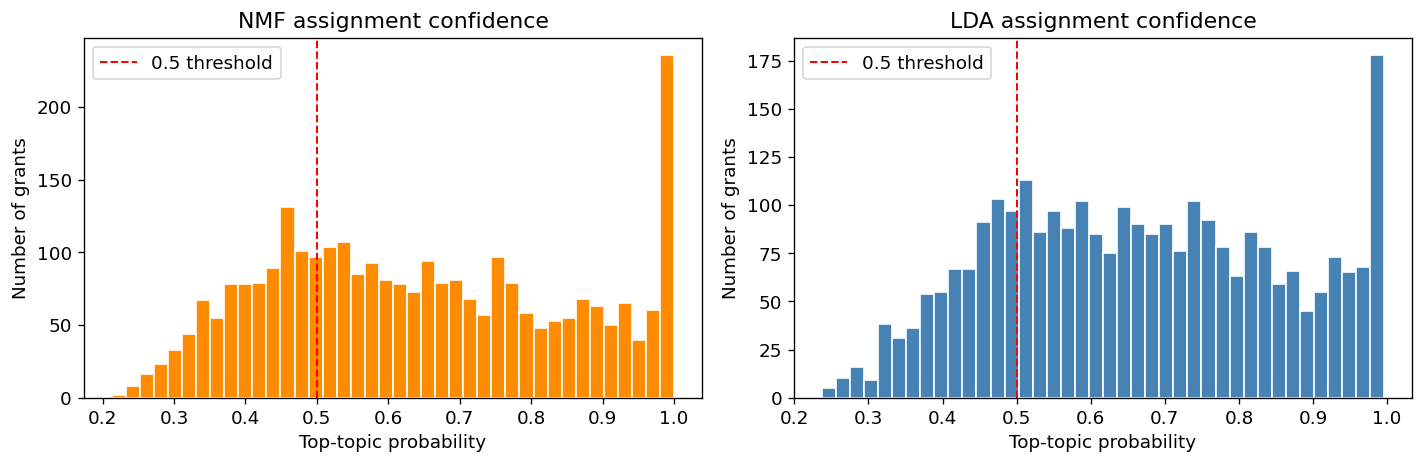

In [9]:
# histogram of assignment confidence for NMF and LDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(aa['nmf_top_prob'], bins=40, color='darkorange', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
axes[0].set_xlabel('Top-topic probability')
axes[0].set_ylabel('Number of grants')
axes[0].set_title('NMF assignment confidence')
axes[0].legend()

axes[1].hist(aa['lda_top_prob'], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
axes[1].set_xlabel('Top-topic probability')
axes[1].set_ylabel('Number of grants')
axes[1].set_title('LDA assignment confidence')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/assignment_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

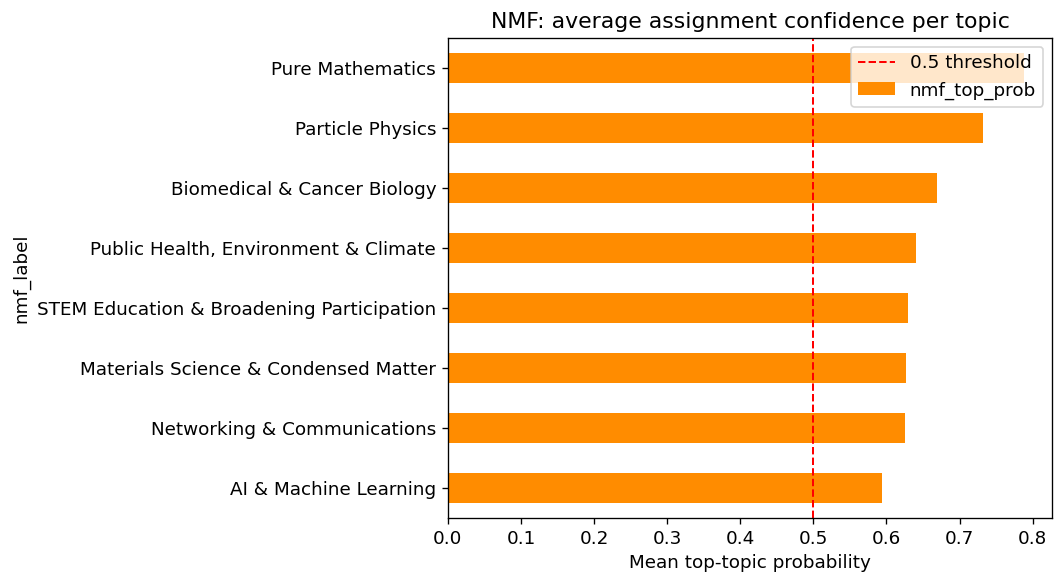

In [10]:
# confidence per topic — are some topics harder to assign than others?
nmf_conf_by_topic = aa.groupby('nmf_label')['nmf_top_prob'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
nmf_conf_by_topic.plot(kind='barh', ax=ax, color='darkorange')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
ax.set_xlabel('Mean top-topic probability')
ax.set_title('NMF: average assignment confidence per topic')
ax.legend()
plt.tight_layout()
plt.savefig('figures/confidence_per_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Manual Spot-Check, Read Actual Abstracts per Topic

In [11]:
# sample 5 grants per NMF topic and print title + first 300 chars of abstract
# read these and judge whether the label makes sense
# high-confidence grants sampled first (top_prob > 0.6)
print('NMF TOPIC SPOT-CHECK — 5 grants per topic')
print('' * 70)

for topic_id, label in nmf_labels.items():
    subset = aa[(aa['nmf_topic'] == topic_id) & (aa['nmf_top_prob'] > 0.6)]
    if len(subset) < 5:
        subset = aa[aa['nmf_topic'] == topic_id]
    sample = subset.sample(min(5, len(subset)), random_state=42)

    print(f'\nTOPIC: {label}  ({(aa["nmf_topic"]==topic_id).sum()} grants)')
    for _, row in sample.iterrows():
        title    = str(row['Title'])[:80] if pd.notna(row['Title']) else 'No title'
        abstract = str(row['Abstract'])[:250] if pd.notna(row['Abstract']) else ''
        print(f'  [{row["nmf_top_prob"]:.2f}] {title}')
        print(f'         {abstract}...')
        print()

NMF TOPIC SPOT-CHECK — 5 grants per topic


TOPIC: AI & Machine Learning  (298 grants)
  [0.68] Enhancing Disabilities Engineering Research and Education Through Robotics Capst
         PI: Padir
Proposal Number: 1264588

Motivation The overarching goal of this proposal is to investigate, design, implement and validate novel robotic technologies for assisting persons with general and age-related disabilities through undergraduate ca...

  [0.89] CPS:Medium: Safe Learning-Enabled Cyberphysical Systems
         In spite of tremendous advances in machine learning, the goal of designing truly autonomous cyber-physical systems (CPS), capable of learning from and interacting with the environment to achieve complex specifications remains elusive.  This research ...

  [0.99] RI: Medium: Learning MDP abstractions for Autonomous Systems using Variational M
         Autonomous systems such as self-driving vehicles, hospital platforms, and household robots have great potential social and economic

## 4. Classifier, Can We Predict Topic from Text?

In [12]:
# train a logistic regression classifier on NMF topic labels
# if it achieves high cross-validation accuracy, the topics are text-separable and trustworthy
# use TF-IDF features, same stopwords, 5-fold stratified cross-validation

tfidf_clf = TfidfVectorizer(stop_words=all_stops, ngram_range=(1, 2),
                             max_features=5000, min_df=3)
X = tfidf_clf.fit_transform(aa['full_text_lemma'])
y = aa['nmf_topic'].values

clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print('Logistic Regression cross-validation accuracy (5-fold):')
for i, s in enumerate(cv_scores):
    print(f'  Fold {i+1}: {s:.3f}')
print(f'  Mean  : {cv_scores.mean():.3f}')
print(f'  Std   : {cv_scores.std():.3f}')
print()

# Interpretation:
# > 0.85 = topics are well-separated and trustworthy
# 0.70-0.85 = reasonable, some overlap between topics
# < 0.70 = topics are noisy, assignments less reliable

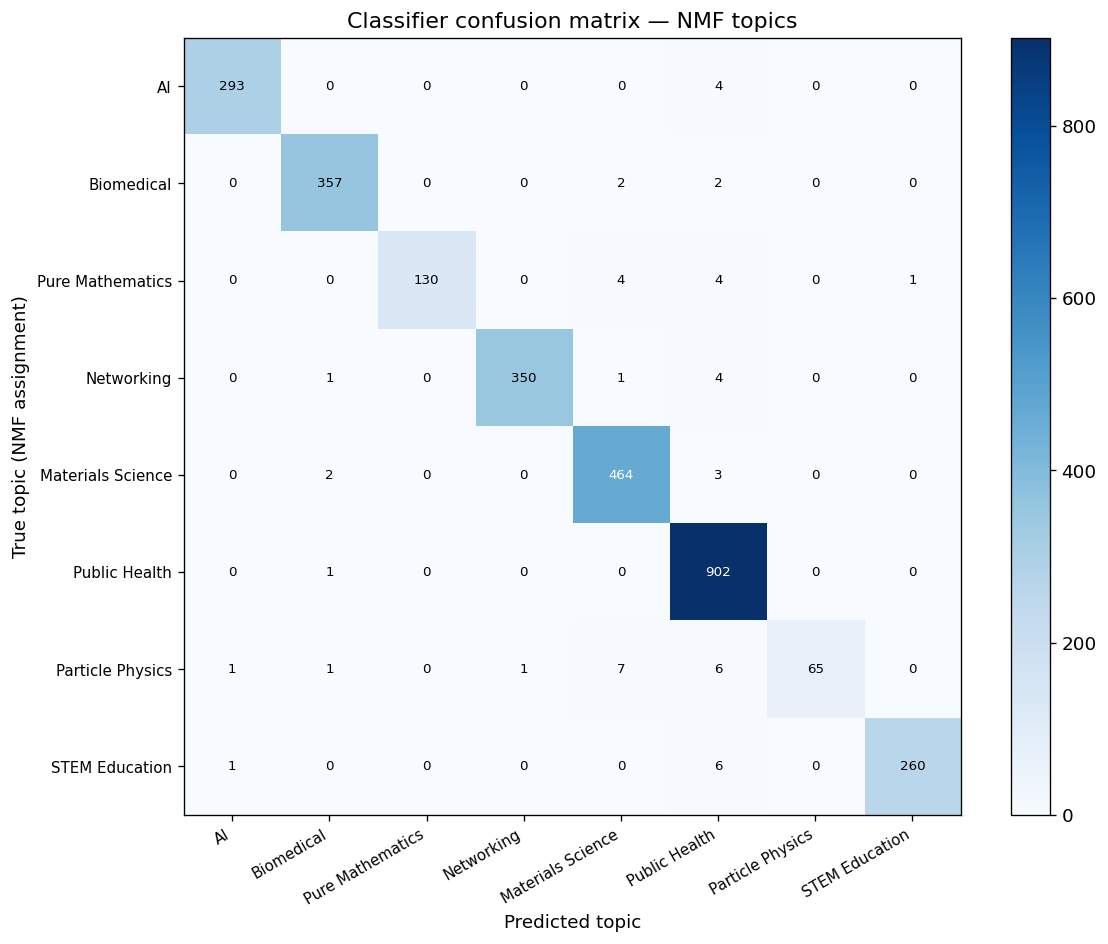


Per-topic classification report:
                   precision    recall  f1-score   support

               AI       0.99      0.99      0.99       297
       Biomedical       0.99      0.99      0.99       361
 Pure Mathematics       1.00      0.94      0.97       139
       Networking       1.00      0.98      0.99       356
Materials Science       0.97      0.99      0.98       469
    Public Health       0.97      1.00      0.98       903
 Particle Physics       1.00      0.80      0.89        81
   STEM Education       1.00      0.97      0.98       267

         accuracy                           0.98      2873
        macro avg       0.99      0.96      0.97      2873
     weighted avg       0.98      0.98      0.98      2873



In [ ]:
# confusion matrix — which topics get confused with each other?
# fit on full dataset and predict to show confusion pattern
clf.fit(X, y)
y_pred = clf.predict(X)

topic_names_short = [nmf_labels[i].split(' &')[0].split(',')[0] for i in range(N_TOPICS)]
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(N_TOPICS))
ax.set_yticks(range(N_TOPICS))
ax.set_xticklabels(topic_names_short, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(topic_names_short, fontsize=9)
plt.colorbar(im, ax=ax)
for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
ax.set_xlabel('Predicted topic')
ax.set_ylabel('True topic (NMF assignment)')
ax.set_title('Classifier confusion matrix — NMF topics')
plt.tight_layout()
plt.savefig('figures/classifier_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-topic classification report:')
print(classification_report(y, y_pred, target_names=topic_names_short))

## 5. UMAP, Visualize Grants in 2D Using BERT Embeddings

In [ ]:
# generate BERT sentence embeddings for all abstracts
# these capture semantic meaning, not just word frequency

try:
    from sentence_transformers import SentenceTransformer
    import umap
    UMAP_OK = True
except ImportError:
    UMAP_OK = False
    print('Missing: pip install sentence-transformers umap-learn')

if UMAP_OK:
    aa['full_text_orig'] = aa['Title'].fillna('') + ' ' + aa['abstract_clean'].fillna('')
    embedder   = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embedder.encode(aa['full_text_orig'].tolist(),
                                  show_progress_bar=True, batch_size=64)
    print(f'Embeddings shape: {embeddings.shape}')

Batches: 100%|██████████| 45/45 [00:10<00:00,  4.21it/s]

Embeddings shape: (2873, 384)


In [ ]:
# reduce to 2D with UMAP
# n_neighbors controls how local vs global the layout is (15 is default)
# min_dist controls how tightly clusters are packed
if UMAP_OK:
    reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.2,
                         metric='cosine', random_state=42)
    coords = reducer.fit_transform(embeddings)
    aa['umap_x'] = coords[:, 0]
    aa['umap_y'] = coords[:, 1]
    print('UMAP done.')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP done.


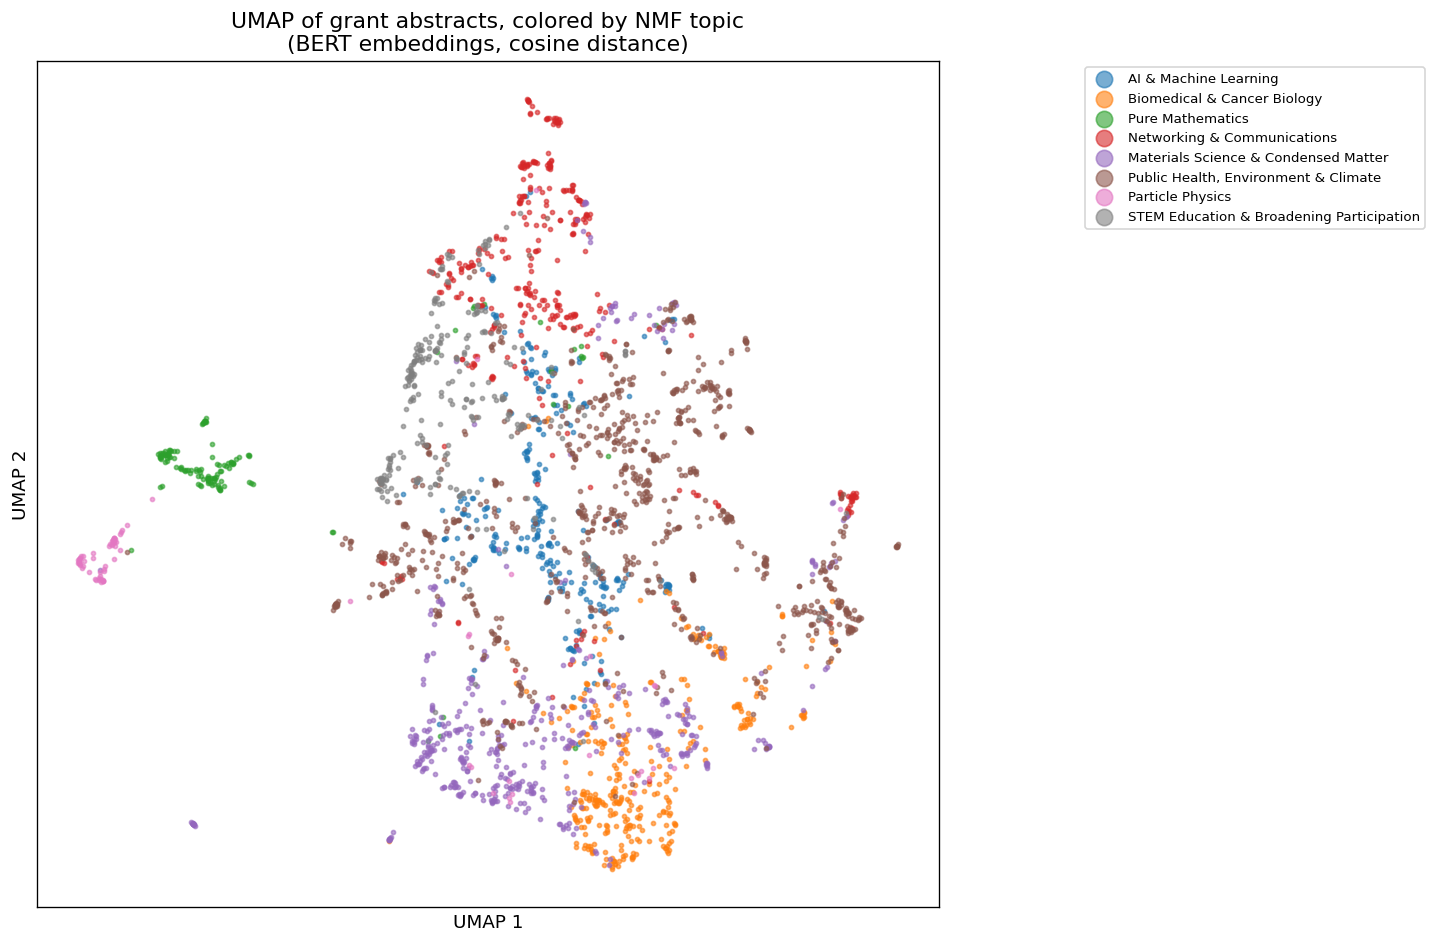

In [ ]:
# UMAP plot colored by NMF topic
# if topics form visible clusters, the NMF assignments reflect real semantic structure
if UMAP_OK:
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(13, 8))
    for topic_id, label in nmf_labels.items():
        mask = aa['nmf_topic'] == topic_id
        ax.scatter(aa.loc[mask, 'umap_x'], aa.loc[mask, 'umap_y'],
                   label=label, s=6, alpha=0.6, color=colors[topic_id])

    ax.legend(fontsize=8, markerscale=4, loc='upper center',
               bbox_to_anchor=(1.35, 1))
    ax.set_title('UMAP of grant abstracts, colored by NMF topic\n(BERT embeddings, cosine distance)')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig('figures/umap_nmf_topics.png', dpi=150, bbox_inches='tight')
    plt.show()

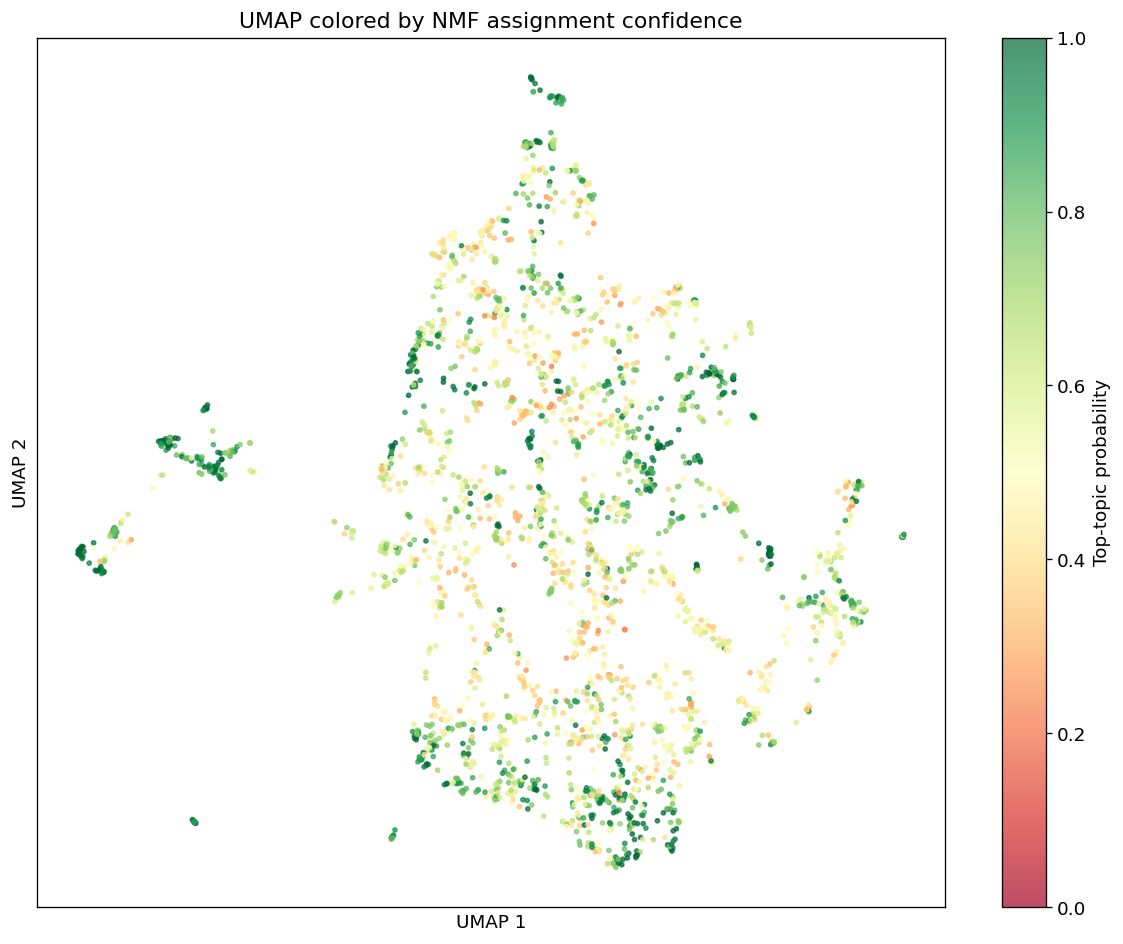

In [ ]:
# UMAP plot colored by assignment confidence
# dark = high confidence, light = ambiguous
if UMAP_OK:
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(aa['umap_x'], aa['umap_y'],
                    c=aa['nmf_top_prob'], cmap='RdYlGn',
                    s=6, alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='Top-topic probability')
    ax.set_title('UMAP colored by NMF assignment confidence')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig('figures/umap_confidence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Within-Topic Deep Dive, What Is Northeastern Actually Doing?

In [ ]:
# for each NMF topic: find the most distinctive terms within that subset
# uses inverse document frequency — low IDF = word is rare outside this topic = distinctive
# this answers: within Biomedical, what specifically is NU working on?
print('WITHIN-TOPIC DISTINCTIVE TERMS')
print(' ' * 60)

within_topic_terms = {}

for topic_id, label in nmf_labels.items():
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 15:
        continue
    tv = TfidfVectorizer(stop_words=all_stops, max_features=300,
                          ngram_range=(1, 2), min_df=2)
    tv.fit_transform(subset)
    # lowest IDF = most characteristic of this topic
    top_terms = pd.Series(tv.idf_, index=tv.get_feature_names_out())\
                  .sort_values().head(20).index.tolist()
    within_topic_terms[label] = top_terms
    print(f'\n{label} ({len(subset)} grants):')
    print('  ' + ' | '.join(top_terms[:15]))

WITHIN-TOPIC DISTINCTIVE TERMS
                                                            

AI & Machine Learning (297 grants):
  learning | evaluation | human | task | application | machine | environment | computer | algorithm | information | machine learning | world | neural | control | improve

Biomedical & Cancer Biology (361 grants):
  cell | description | mechanism | human | applicant | description applicant | function | role | disease | drug | molecular | protein | tissue | cellular | vivo

Pure Mathematics (139 grants):
  theory | geometry | algebraic | mathematics | algebra | mathematical | structure | geometric | application | physic | object | space | connection | invariant | algebraic geometry

Networking & Communications (356 grants):
  network | application | evaluation | communication | wireless | software | security | algorithm | information | existing | power | platform | low | access | networking

Materials Science & Condensed Matter (469 grants):
  material | struct

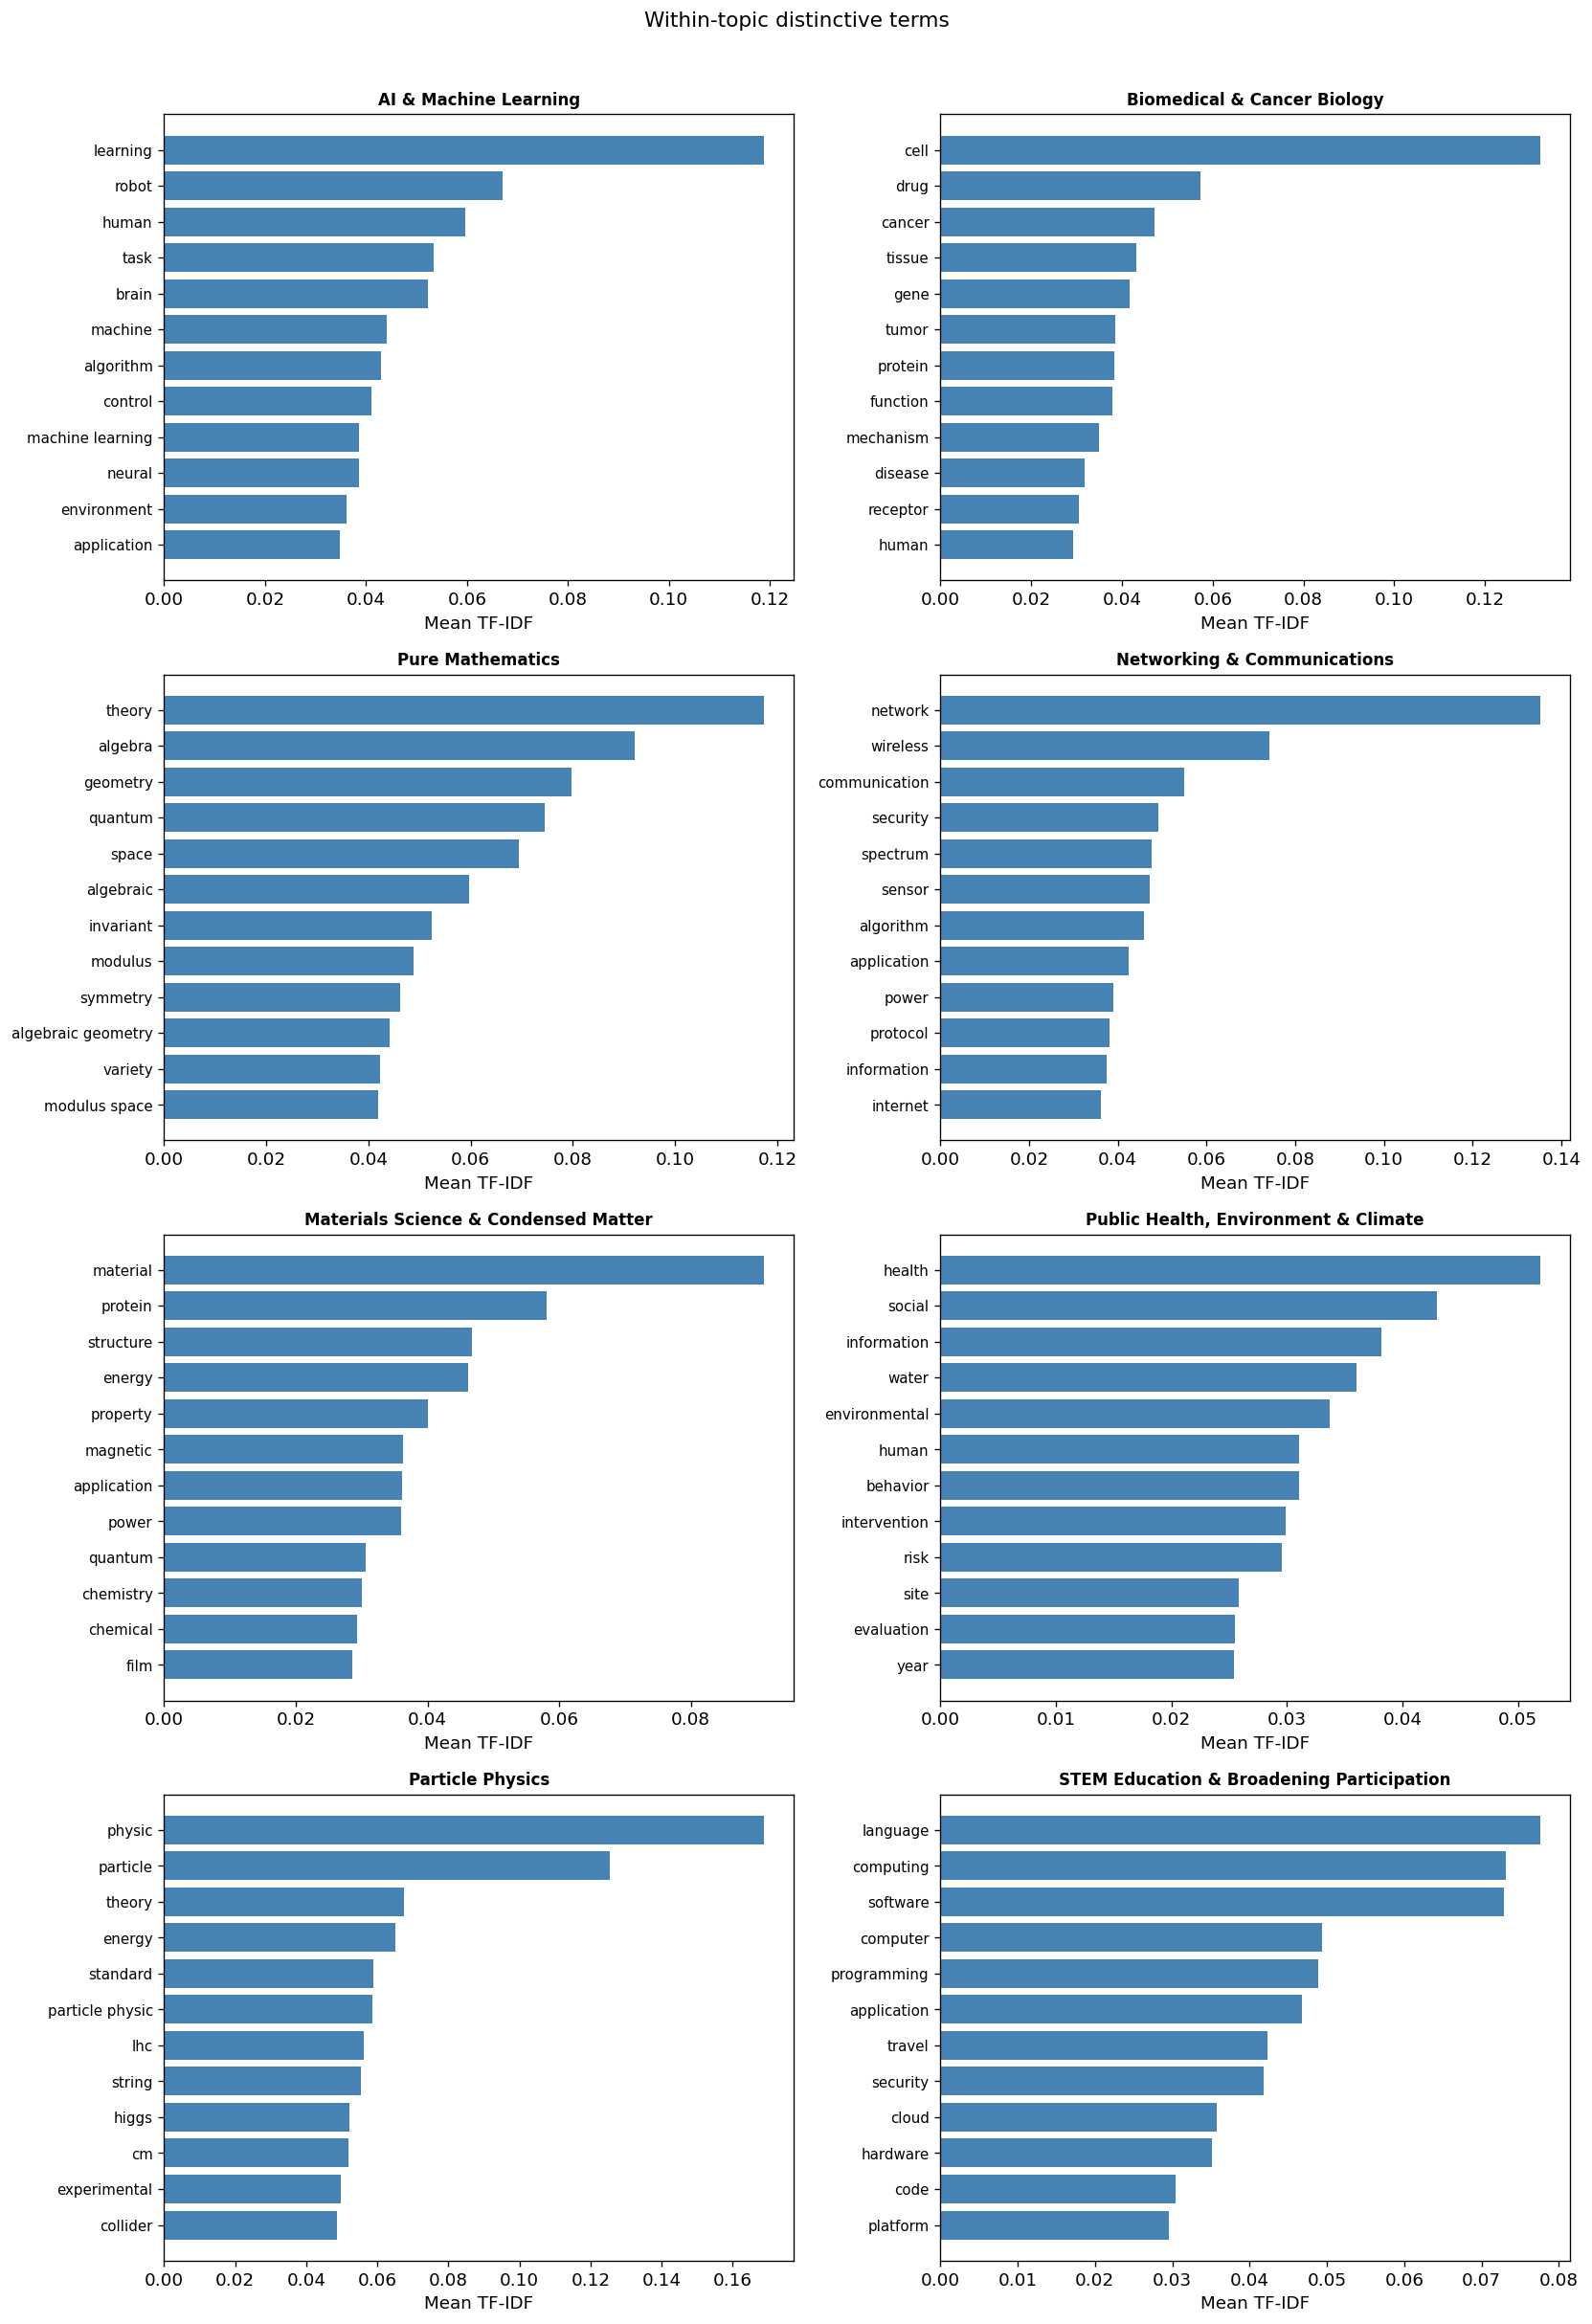

In [ ]:
# visualize within-topic terms as small bar charts (one panel per topic)
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, (topic_id, label) in enumerate(nmf_labels.items()):
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 15:
        axes[idx].set_visible(False)
        continue
    tv = TfidfVectorizer(stop_words=all_stops, max_features=300,
                          ngram_range=(1, 2), min_df=2)
    mat = tv.fit_transform(subset)
    mean_tfidf = mat.toarray().mean(axis=0)
    top = pd.Series(mean_tfidf, index=tv.get_feature_names_out())\
            .sort_values(ascending=False).head(12).sort_values()

    axes[idx].barh(range(len(top)), top.values, color='steelblue')
    axes[idx].set_yticks(range(len(top)))
    axes[idx].set_yticklabels(top.index, fontsize=9)
    axes[idx].set_title(label, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF')

plt.suptitle('Within-topic distinctive terms',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('figures/within_topic_terms.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# sub-topic modeling: run NMF within each topic with n=3 sub-topics
# this reveals the internal structure of each broad area
print('SUB-TOPICS WITHIN EACH NMF TOPIC (n=3 each)')
print(' ' * 60)

for topic_id, label in nmf_labels.items():
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 30:
        print(f'\n{label}: too few grants for sub-topics ({len(subset)})')
        continue

    tv  = TfidfVectorizer(stop_words=all_stops, max_features=1000,
                           ngram_range=(1, 2), min_df=2, max_df=0.8)
    mat = tv.fit_transform(subset)
    sub_nmf  = NMF(n_components=3, random_state=42, max_iter=300)
    sub_nmf.fit(mat)
    names = tv.get_feature_names_out()

    print(f'\n{label} ({len(subset)} grants):')
    for i, comp in enumerate(sub_nmf.components_):
        words = [names[j] for j in comp.argsort()[:-8:-1]]
        print(f'  Sub-{i+1}: {" | ".join(words)}')

SUB-TOPICS WITHIN EACH NMF TOPIC (n=3 each)
                                                            

AI & Machine Learning (297 grants):
  Sub-1: learning | machine | machine learning | algorithm | brain | neural | application
  Sub-2: worker | manufacturing | skill | intelligent | ixr | job | precision
  Sub-3: robot | human | human robot | object | control | task | autonomous

Biomedical & Cancer Biology (361 grants):
  Sub-1: cell | tissue | gene | mechanical | function | biology | network
  Sub-2: tumor | cancer | drug | therapy | delivery | cell | lung
  Sub-3: compound | drug | receptor | lead | ligand | agonist | inhibitor

Pure Mathematics (139 grants):
  Sub-1: modulus | space | modulus space | sheaf | geometry | variety | curve
  Sub-2: algebra | quantum | noncommutative | cluster | international | auslander | invariant
  Sub-3: postdoctoral | geometry | algebraic geometry | algebraic | mentoring | geometry theory | course

Networking & Communications (356 grants):
  Sub

In [ ]:
# summary: confidence and coherence side by side
summary = pd.DataFrame({
    'topic':       [nmf_labels[i] for i in range(N_TOPICS)],
    'num_grants':  [int((aa['nmf_topic'] == i).sum()) for i in range(N_TOPICS)],
    'coherence':   [round(s, 3) for s in nmf_coherence],
    'mean_conf':   [round(aa[aa['nmf_topic']==i]['nmf_top_prob'].mean(), 3) for i in range(N_TOPICS)],
    'high_conf_pct': [round((aa[aa['nmf_topic']==i]['nmf_top_prob'] > 0.6).mean() * 100, 1)
                      for i in range(N_TOPICS)],
}).set_index('topic').sort_values('coherence', ascending=False)

print('NMF topic quality summary:')
print(summary.to_string())

NMF topic quality summary:
                                           num_grants  coherence  mean_conf  high_conf_pct
topic                                                                                     
Particle Physics                                   81      0.603      0.733           65.4
Pure Mathematics                                  139      0.457      0.788           79.9
Biomedical & Cancer Biology                       361      0.316      0.670           54.6
Networking & Communications                       356      0.301      0.626           52.5
STEM Education & Broadening Participation         267      0.280      0.629           52.1
Materials Science & Condensed Matter              469      0.242      0.626           49.0
AI & Machine Learning                             297      0.220      0.595           40.4
Public Health, Environment & Climate              903      0.122      0.639           54.7
